# TS6: Primeras nociones de estimación espectral: Ancho de banda de señales.

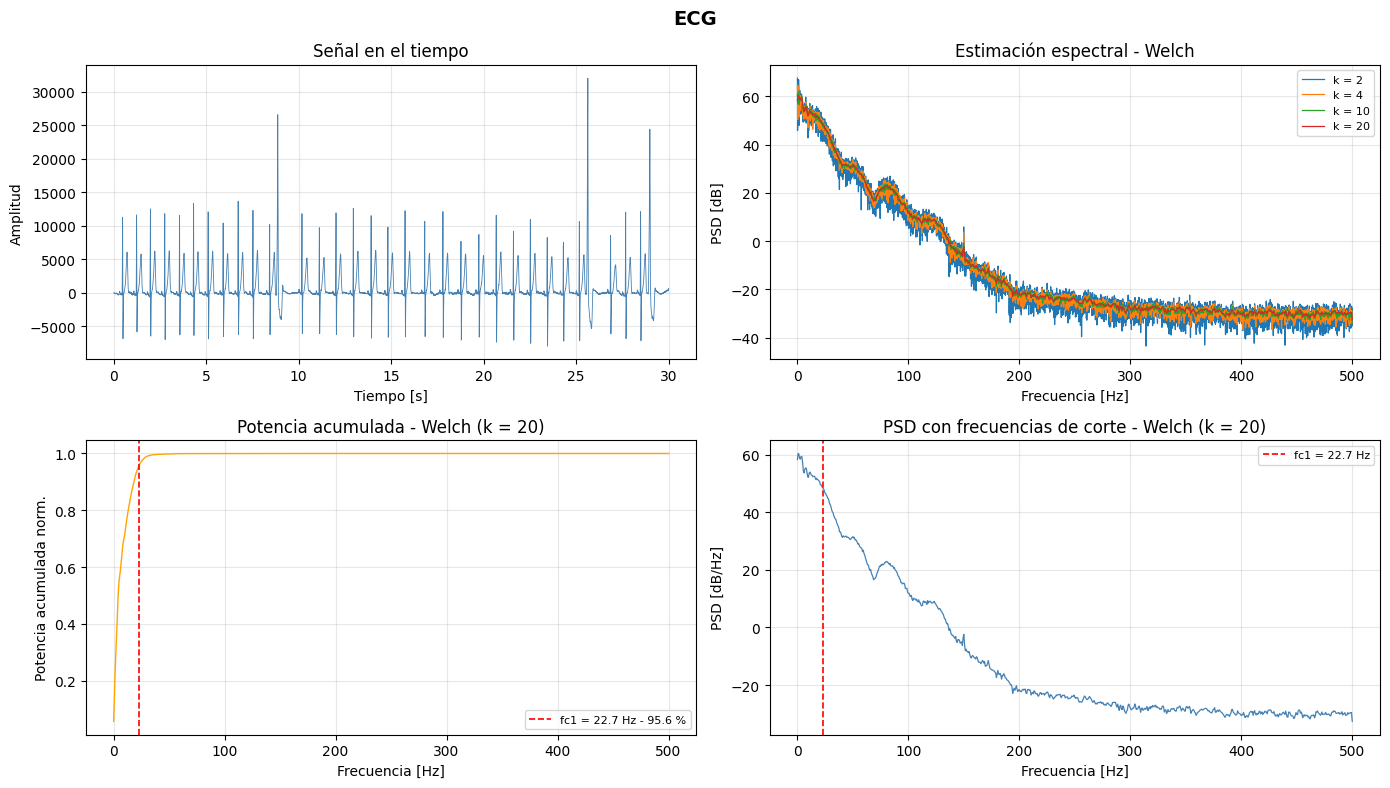

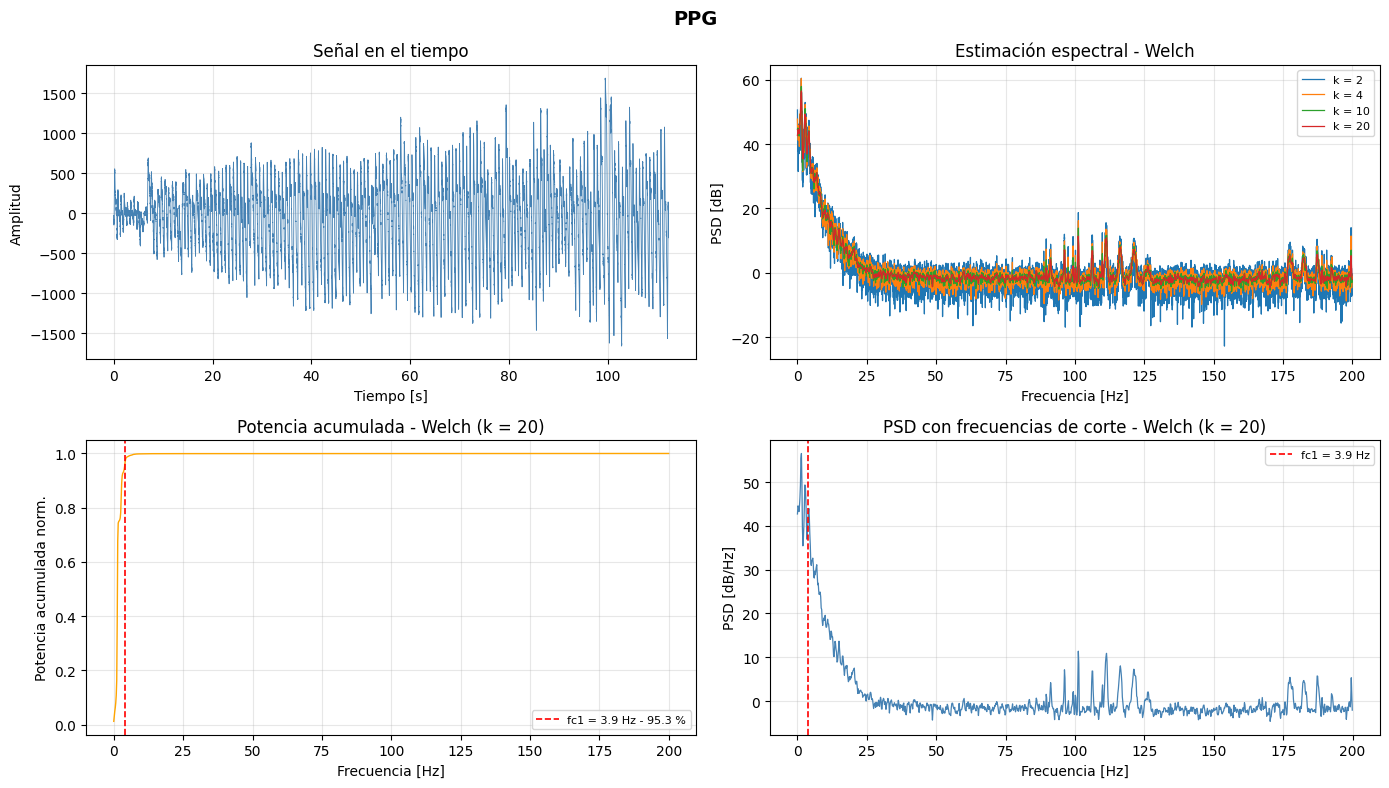

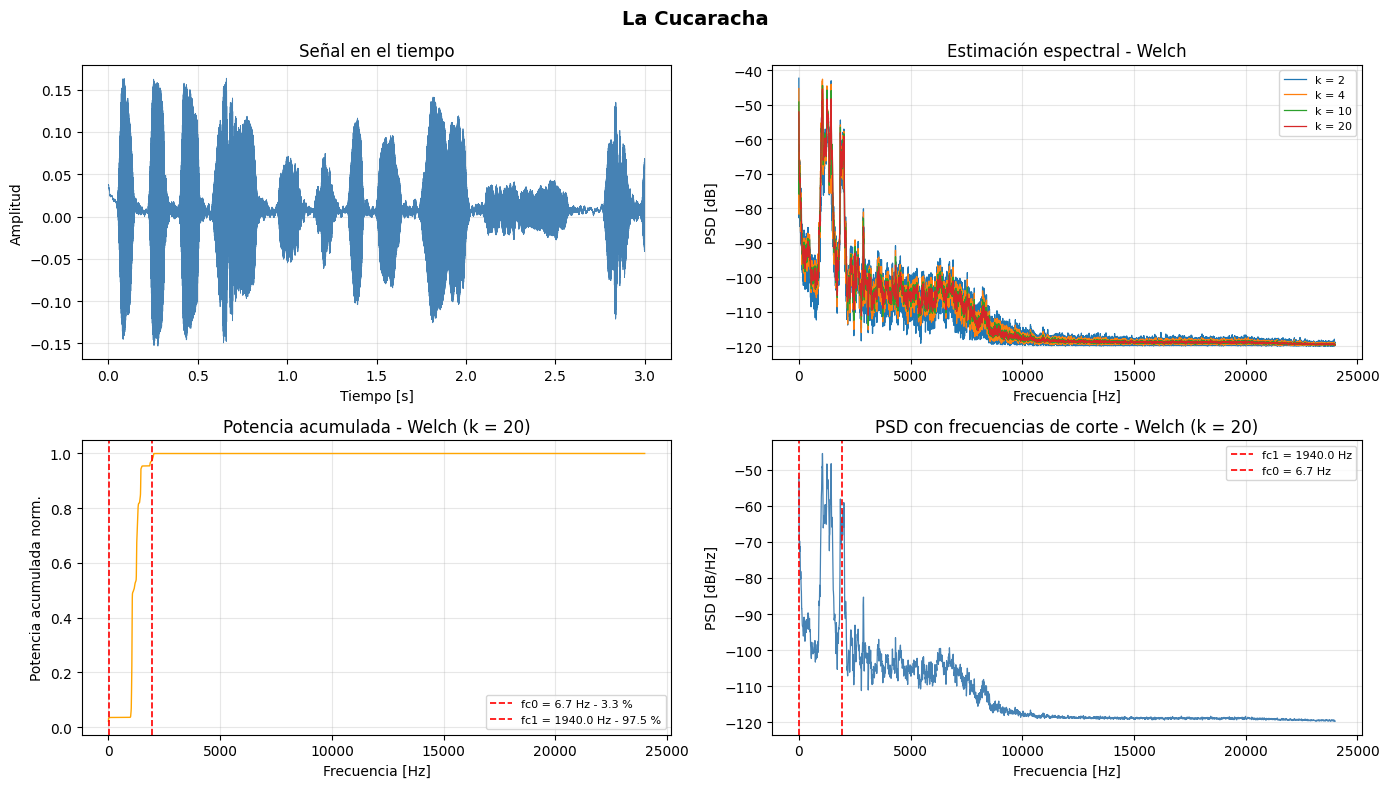

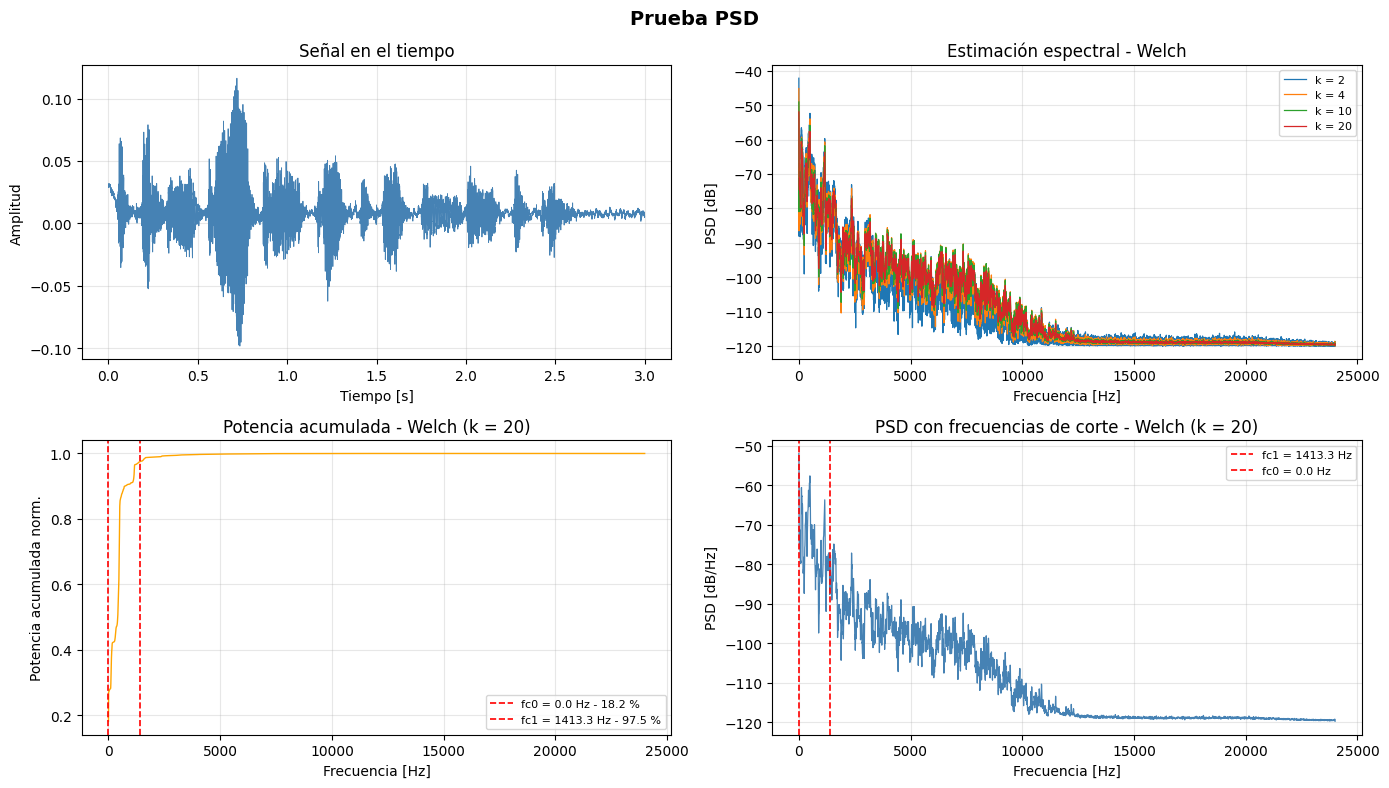

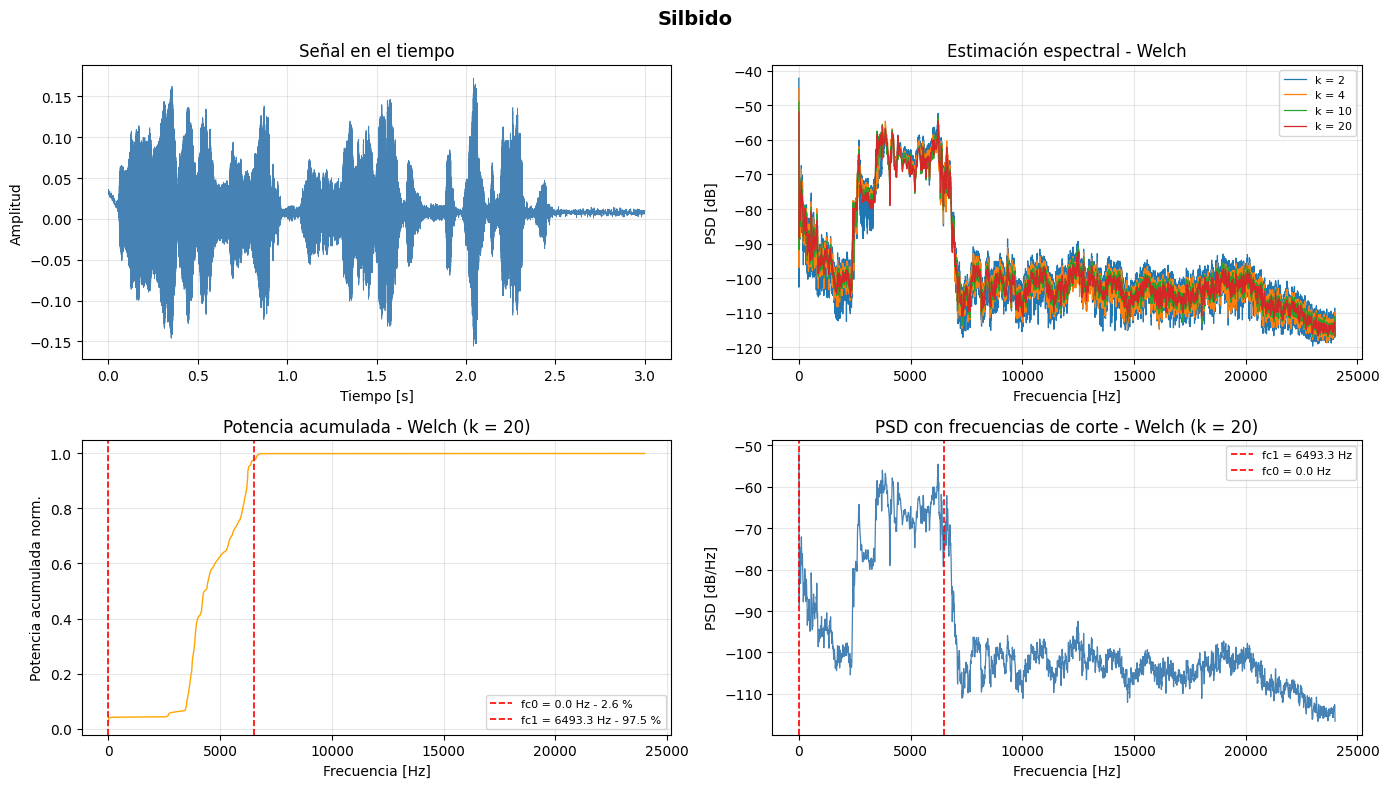

In [34]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio


### Señales ###
PASABAJOS  = 0
PASABANDA  = 1

fs_ecg = 1000   # Hz
fs_ppg = 400    # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')
ppg          = np.load('ppg_sin_ruido.npy')

fs_cuc,   wav_cuc   = sio.wavfile.read('la cucaracha.wav')
fs_prueba, wav_prueba = sio.wavfile.read('prueba psd.wav')
fs_silb,  wav_silb  = sio.wavfile.read('silbido.wav')

data_dict = {
    "ECG"        : [ecg_one_lead, fs_ecg,    PASABAJOS],
    "PPG"        : [ppg,          fs_ppg,    PASABAJOS],
    "La Cucaracha": [wav_cuc,     fs_cuc,    PASABANDA],
    "Prueba PSD" : [wav_prueba,   fs_prueba, PASABANDA],
    "Silbido"    : [wav_silb,     fs_silb,   PASABANDA],
}

###  Parámetros de Welch ###
k_list = [2, 4, 10, 20]

# Diccionario de resultados para la tabla comparativa
bw_results = {}   # bw_results[name] = {'tipo': ..., 'welch': ..., 'periodograma': ..., 'blackman_tukey': ...}

for name, (x, fs, tipo) in data_dict.items():

    N = len(x)
    t = np.arange(N) / fs

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(name, fontsize=14, fontweight='bold')

    # Señal en el tiempo
    ax = axes[0, 0]
    ax.plot(t, x, linewidth=0.6, color='steelblue')
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Amplitud")
    ax.set_title("Señal en el tiempo")
    ax.grid(True, alpha=0.3)

    # PSD Welch para distintos k
    ax = axes[0, 1]
    for k in k_list:
        nperseg = N // k
        f, Pxx = sig.welch(x, fs=fs, nperseg=nperseg, noverlap=None,
                           detrend=False, return_onesided=True,
                           scaling='density', average='mean')
        ax.plot(f, 10 * np.log10(Pxx + 1e-12), label=f'k = {k}', linewidth=0.9)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("PSD [dB]")
    ax.set_title("Estimación espectral - Welch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Para el último k estimo el ancho de banda
    Fx = np.cumsum(Pxx)
    Fx = Fx / Fx[-1]    # potencia acumulada normalizada

    # Potencia acumulada
    ax = axes[1, 0]
    ax.plot(f, Fx, color='orange', linewidth=1)
    # Frecuencias de corte en Hz
    if tipo == PASABAJOS:
        idx1 = np.argwhere(Fx > 0.95)[0, 0]
        fc1  = f[idx1]
    else:
        idx0 = np.argwhere(Fx > 0.025)[0, 0]
        idx1 = np.argwhere(Fx > 0.975)[0, 0]
        fc0 = f[idx0]
        fc1 = f[idx1]
        ax.axvline(x=fc0, linewidth=1.2, linestyle='--', color='red', label=f"fc0 = {fc0:.1f} Hz - {Fx[idx0]*100:.1f} %")

    ax.axvline(x=fc1, linewidth=1.2, linestyle='--', color='red', label=f"fc1 = {fc1:.1f} Hz - {Fx[idx1]*100:.1f} %")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Potencia acumulada norm.")
    ax.set_title(f"Potencia acumulada - Welch (k = {k_list[-1]})")

    # Guardar resultado para tabla comparativa
    bw_results.setdefault(name, {'tipo': tipo})
    if tipo == PASABAJOS:
        bw_results[name]['welch'] = f"{fc1:.1f} Hz"
    else:
        bw_results[name]['welch'] = f"{fc0:.1f} – {fc1:.1f} Hz"
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # PSD y frecuencias de corte
    ax = axes[1, 1]
    ax.plot(f, 10 * np.log10(Pxx + 1e-12), color='steelblue', linewidth=0.9)
    ax.axvline(x=fc1, linewidth=1.2, linestyle='--', color='red',
                   label=f"fc1 = {fc1:.1f} Hz")
    if tipo == PASABANDA:
      ax.axvline(x=fc0, linewidth=1.2, linestyle='--', color='red',
                   label=f"fc0 = {fc0:.1f} Hz")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("PSD [dB/Hz]")
    ax.set_title(f"PSD con frecuencias de corte - Welch (k = {k_list[-1]})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

plt.show()

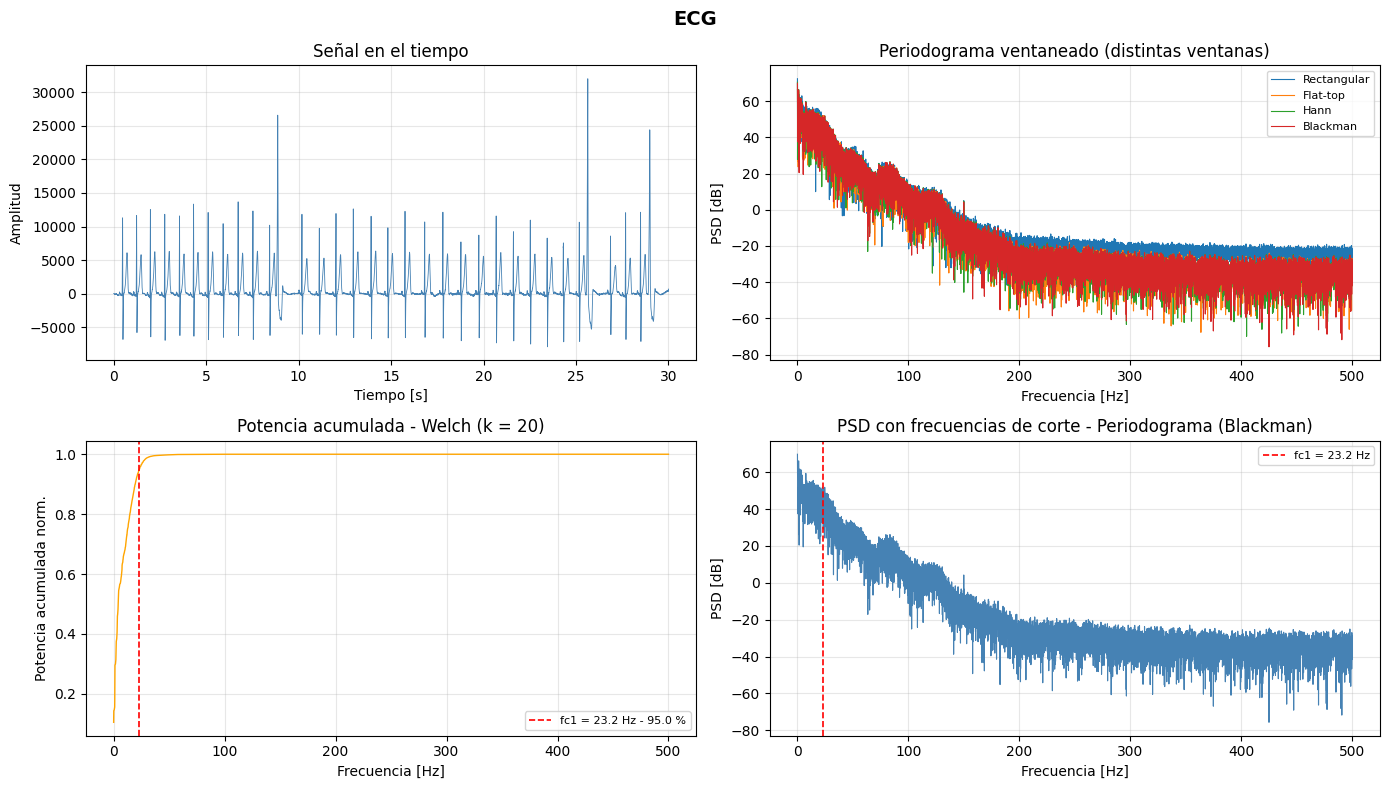

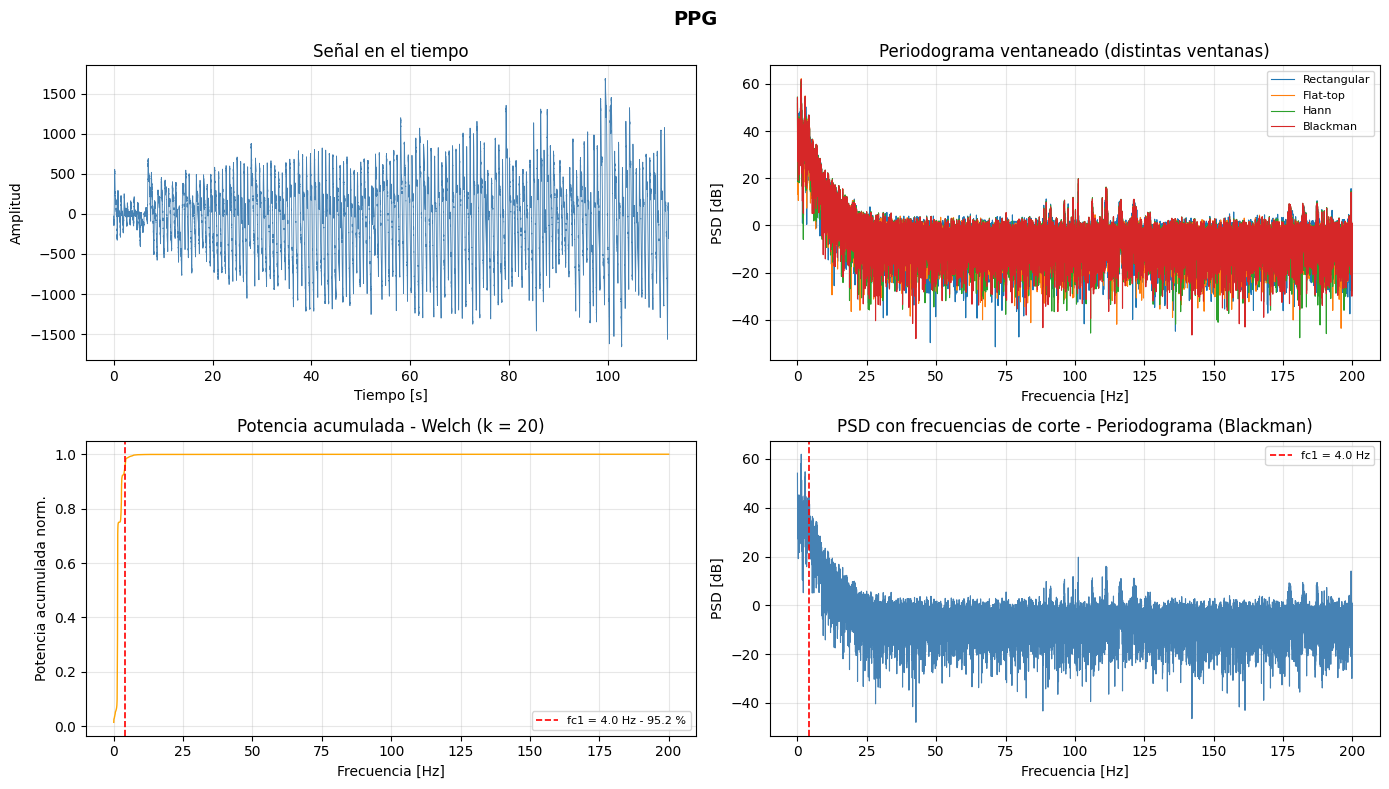

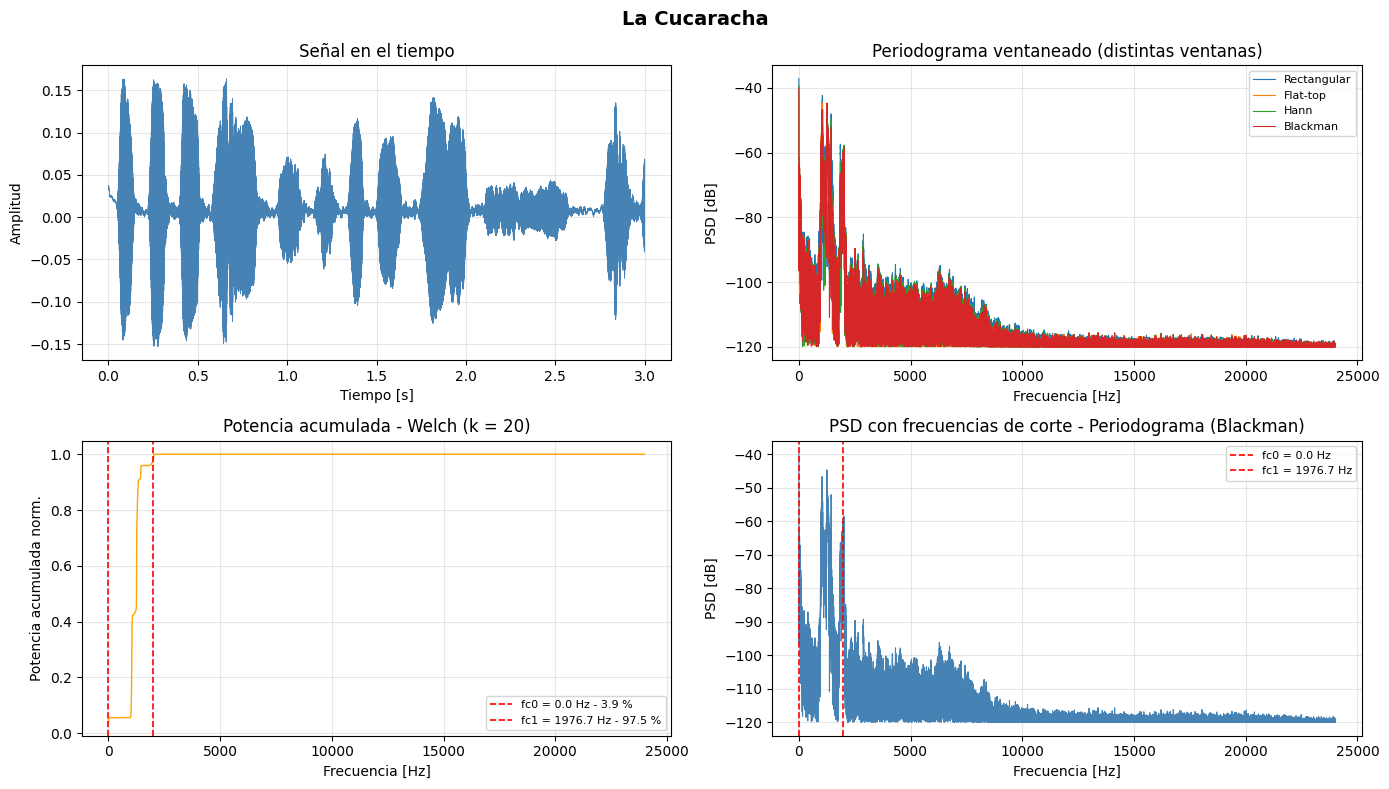

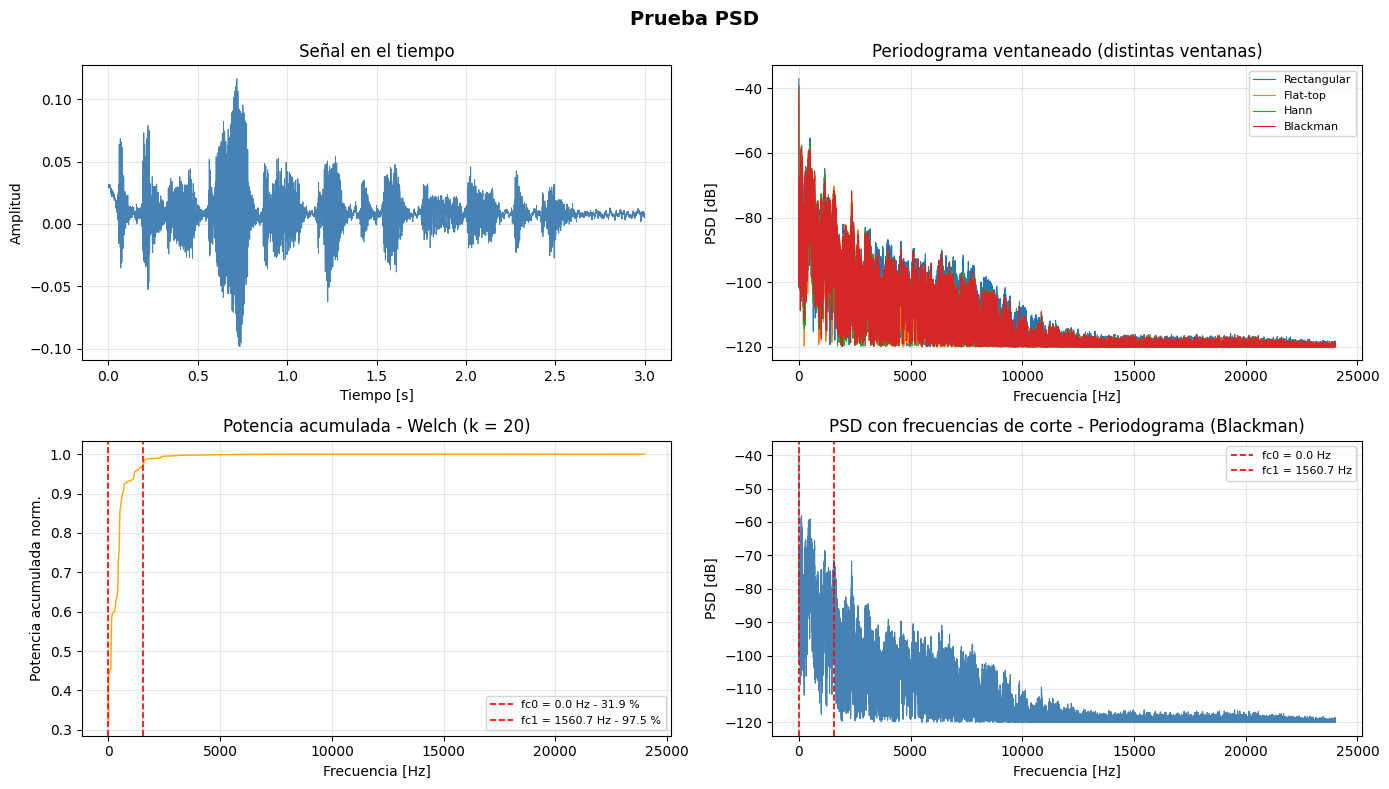

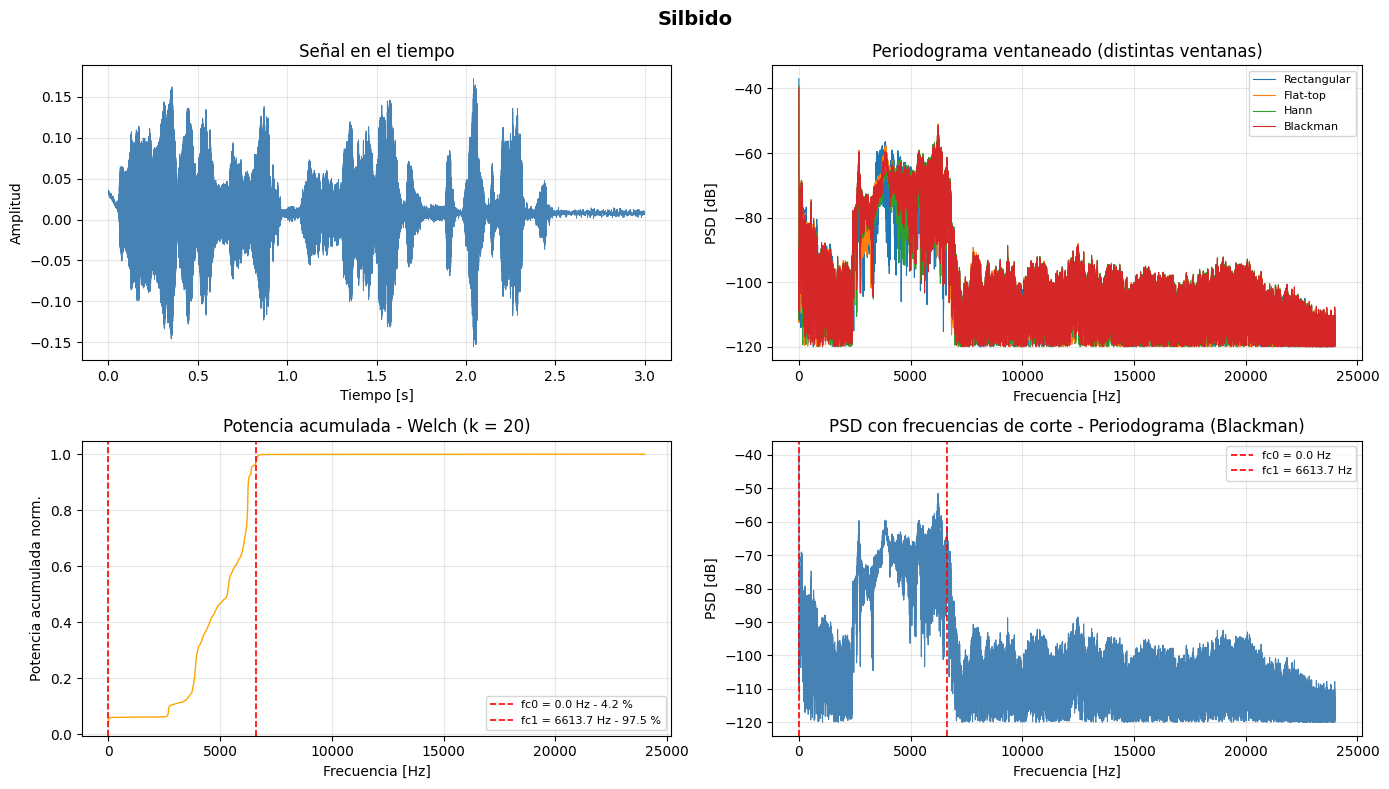

In [35]:
### Periodograma ventaneado ###

window_list = {
    'Rectangular': sig.windows.boxcar,
    'Flat-top'   : sig.windows.flattop,
    'Hann'       : sig.windows.hann,
    'Blackman'   : sig.windows.blackman,
}

def periodograma_ventaneado(x, fs, ventana_fn):
    x = np.asarray(x).ravel().astype(float)
    N = len(x)
    w = ventana_fn(N)
    Px = (np.abs(np.fft.fft(x * w, n=N))**2 / (np.sum(w**2) * fs))[:N//2]
    f  = np.fft.rfftfreq(N, d=1/fs)[:N//2]
    return f, Px

for name, (x, fs, tipo) in data_dict.items():
    N = len(x)
    t = np.arange(N) / fs

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(name, fontsize=14, fontweight='bold')

    # Señal en el tiempo
    ax = axes[0, 0]
    ax.plot(t, x, linewidth=0.6, color='steelblue')
    ax.set_xlabel("Tiempo [s]"); ax.set_ylabel("Amplitud")
    ax.set_title("Señal en el tiempo"); ax.grid(True, alpha=0.3)

    # PSD con distintas ventanas
    ax = axes[0, 1]
    for wname, wfn in window_list.items():
        f, Pxx = periodograma_ventaneado(x, fs, wfn)
        ax.plot(f, 10*np.log10(Pxx + 1e-12), label=wname, linewidth=0.8)
    ax.set_xlabel("Frecuencia [Hz]");
    ax.set_ylabel("PSD [dB]")
    ax.set_title("Periodograma ventaneado (distintas ventanas)")
    ax.legend(fontsize=8);
    ax.grid(True, alpha=0.3)

    f, Pxx = periodograma_ventaneado(x, fs, sig.windows.blackman)

    Fx = np.cumsum(Pxx);
    Fx /= Fx[-1]

    # Potencia acumulada
    ax = axes[1, 0]
    ax.plot(f, Fx, color='orange', linewidth=1)
    # Frecuencias de corte en Hz
    if tipo == PASABAJOS:
        idx1 = np.argwhere(Fx > 0.95)[0, 0]
        fc1  = f[idx1]
    else:
        idx0 = np.argwhere(Fx > 0.025)[0, 0]
        idx1 = np.argwhere(Fx > 0.975)[0, 0]
        fc0 = f[idx0]
        fc1 = f[idx1]
        ax.axvline(x=fc0, linewidth=1.2, linestyle='--', color='red', label=f"fc0 = {fc0:.1f} Hz - {Fx[idx0]*100:.1f} %")

    ax.axvline(x=fc1, linewidth=1.2, linestyle='--', color='red', label=f"fc1 = {fc1:.1f} Hz - {Fx[idx1]*100:.1f} %")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Potencia acumulada norm.")
    ax.set_title(f"Potencia acumulada - Welch (k = {k_list[-1]})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Guardar resultado para tabla comparativa
    bw_results.setdefault(name, {'tipo': tipo})
    if tipo == PASABAJOS:
        bw_results[name]['periodograma'] = f"{fc1:.1f} Hz"
    else:
        bw_results[name]['periodograma'] = f"{fc0:.1f} – {fc1:.1f} Hz"

    ax = axes[1, 1]
    ax.plot(f, 10*np.log10(Pxx + 1e-12), color='steelblue', linewidth=0.8)
    if tipo == 1:
        ax.axvline(fc0, linewidth=1.2, linestyle='--', color='red',
                   label=f"fc0 = {fc0:.1f} Hz")
    ax.axvline(fc1, linewidth=1.2, linestyle='--', color='red',
               label=f"fc1 = {fc1:.1f} Hz")
    ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("PSD [dB]")
    ax.set_title("PSD con frecuencias de corte - Periodograma (Blackman)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()

plt.show()


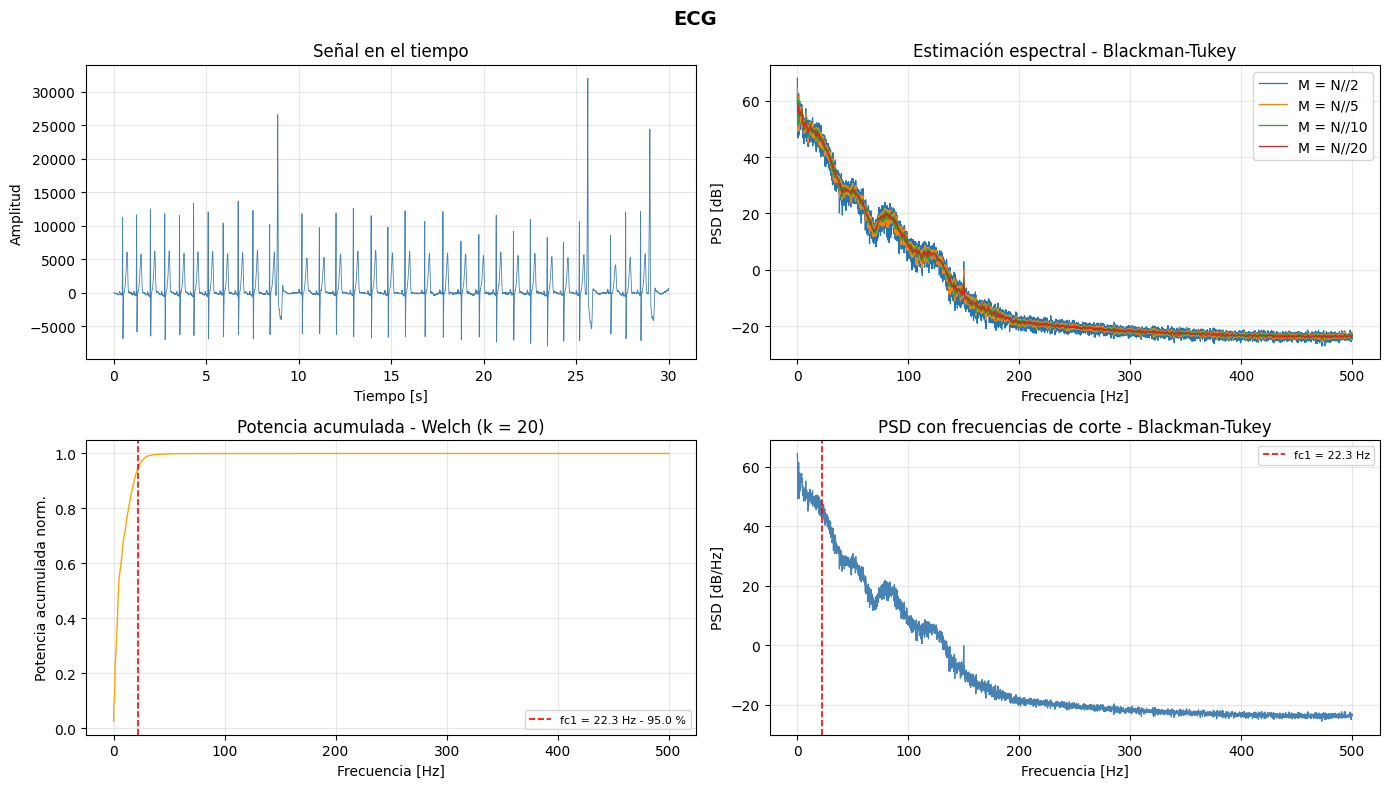

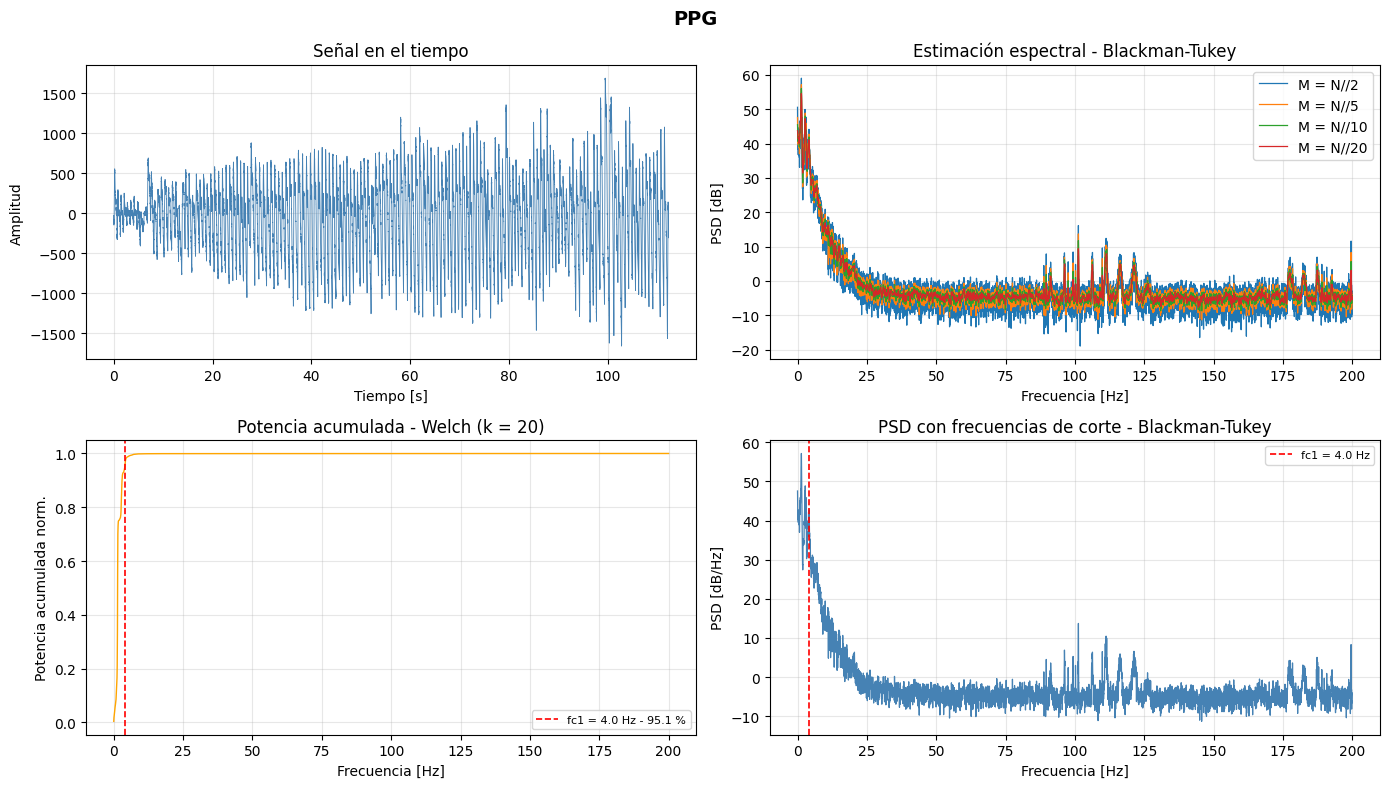

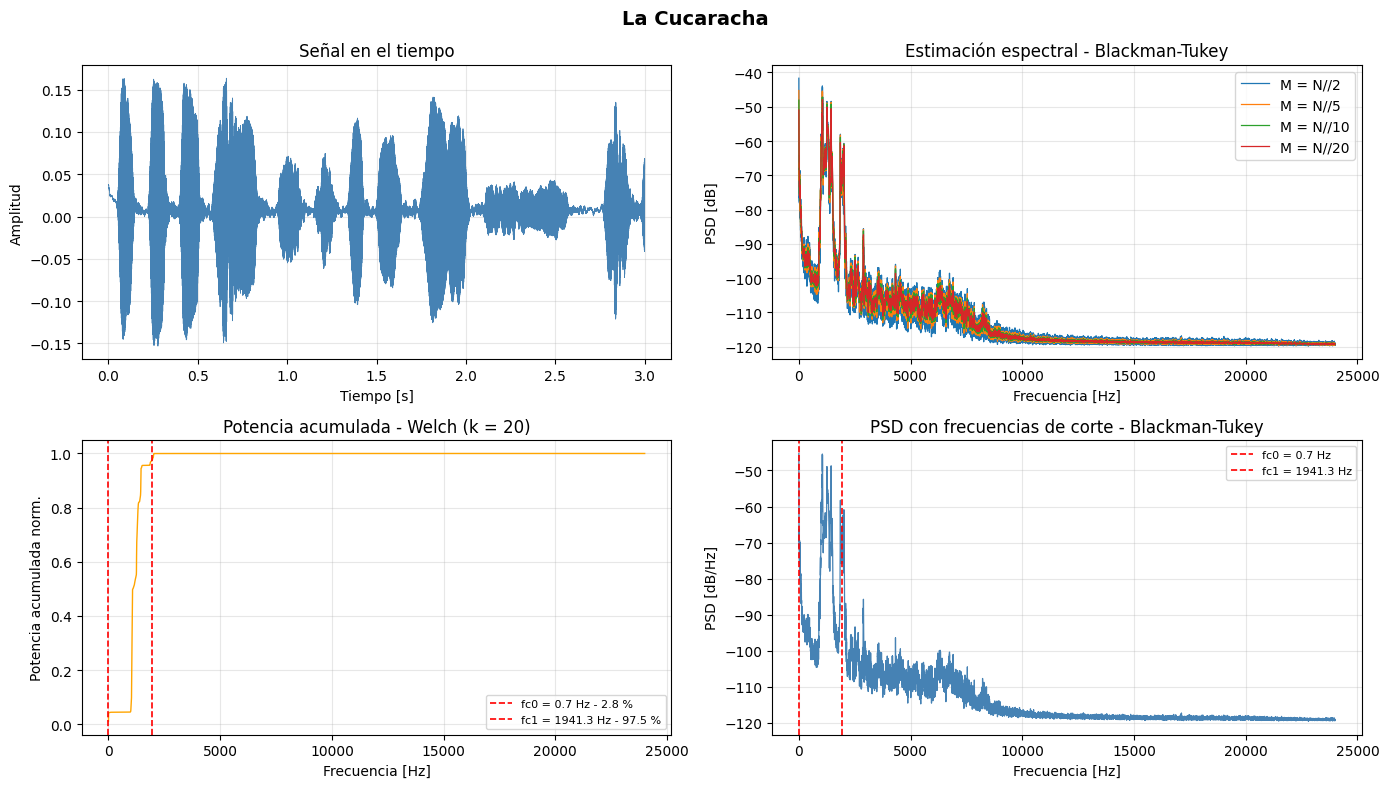

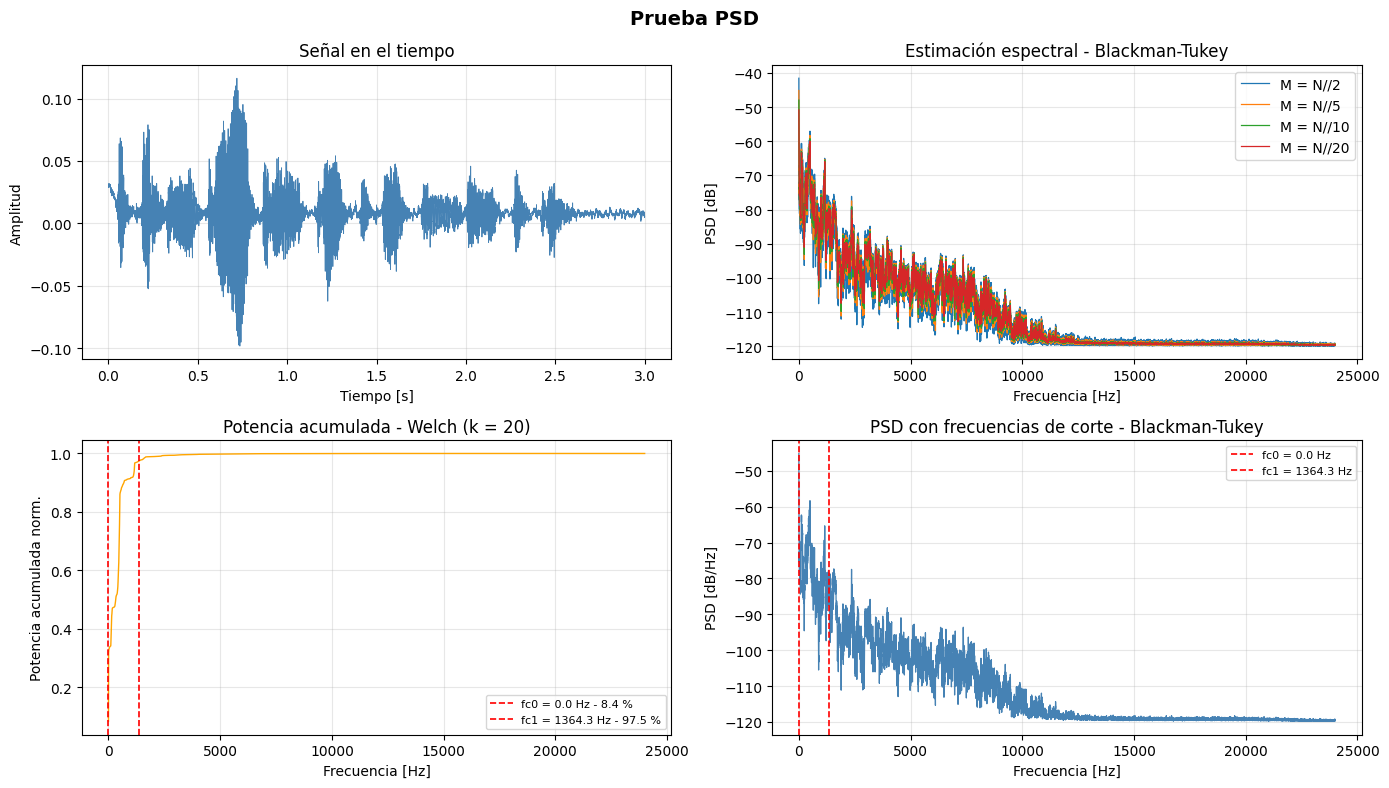

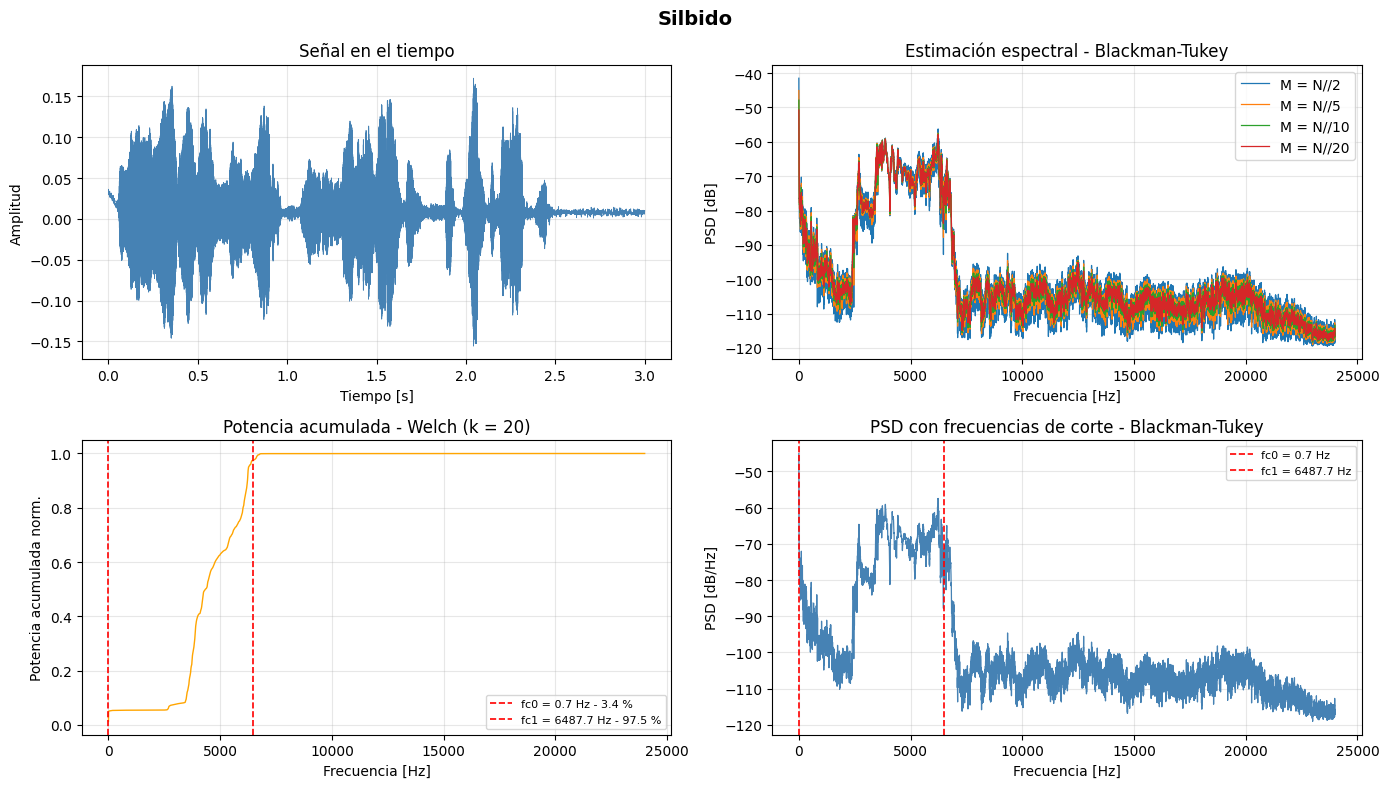

In [36]:
###  Blackman-Tukey ###
def blackman_tukey(x, M=None, fs=1000):
    x = np.asarray(x).ravel().astype(float)
    N = len(x)
    if M is None:
        M = N // 5

    # autocorrelación con toda la señal, lags centrados en 0
    r_full = np.correlate(x, x, mode='full') / (N*fs)
    mid = len(r_full) // 2
    r = r_full[mid-(M-1) : mid+M]          # longitud 2M-1

    w = sig.windows.blackman(2*M - 1)
    # FFT de la autocorr ventaneada = PSD
    Px = np.abs(np.fft.fft(r * w, n=N))[:N//2]
    f = np.fft.rfftfreq(N, d=1/fs)[:N//2]
    return f, Px

for name, (x, fs, tipo) in data_dict.items():
    N = len(x)
    t = np.arange(N)/fs

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(name, fontsize=14, fontweight='bold')

    # Señal en el tiempo
    ax = axes[0, 0]
    ax.plot(t, x, linewidth=0.6, color='steelblue')
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Amplitud")
    ax.set_title("Señal en el tiempo")
    ax.grid(True, alpha=0.3)

    # PSD Welch para distintos k
    ax = axes[0, 1]
    M_list = [N//2, N//5, N//10, N//20]
    for M in M_list:
      f, Pxx = blackman_tukey(x, M=M, fs=fs)
      ax.plot(f, 10 * np.log10(Pxx + 1e-12), linewidth=0.9, label=f"M = N//{N//M}")
    ax.legend()
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("PSD [dB]")
    ax.set_title("Estimación espectral - Blackman-Tukey")
    ax.grid(True, alpha=0.3)

    M = N//5
    f, Pxx = blackman_tukey(x, M=M, fs=fs)
    # Para el M=N//5 estimo el ancho de banda
    Fx = np.cumsum(Pxx)
    Fx = Fx / Fx[-1]    # potencia acumulada normalizada

    # Potencia acumulada
    ax = axes[1, 0]
    ax.plot(f, Fx, color='orange', linewidth=1)
    # Frecuencias de corte en Hz
    if tipo == PASABAJOS:
        idx1 = np.argwhere(Fx > 0.95)[0, 0]
        fc1  = f[idx1]
    else:
        idx0 = np.argwhere(Fx > 0.025)[0, 0]
        idx1 = np.argwhere(Fx > 0.975)[0, 0]
        fc0 = f[idx0]
        fc1 = f[idx1]
        ax.axvline(x=fc0, linewidth=1.2, linestyle='--', color='red', label=f"fc0 = {fc0:.1f} Hz - {Fx[idx0]*100:.1f} %")

    ax.axvline(x=fc1, linewidth=1.2, linestyle='--', color='red', label=f"fc1 = {fc1:.1f} Hz - {Fx[idx1]*100:.1f} %")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Potencia acumulada norm.")
    ax.set_title(f"Potencia acumulada - Welch (k = {k_list[-1]})")

    # Guardar resultado para tabla comparativa
    bw_results.setdefault(name, {'tipo': tipo})
    if tipo == PASABAJOS:
        bw_results[name]['blackman_tukey'] = f"{fc1:.1f} Hz"
    else:
        bw_results[name]['blackman_tukey'] = f"{fc0:.1f} – {fc1:.1f} Hz"
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # PSD y frecuencias de corte
    ax = axes[1, 1]
    ax.plot(f, 10 * np.log10(Pxx + 1e-12), color='steelblue', linewidth=0.9)
    if tipo == PASABANDA:
      ax.axvline(x=fc0, linewidth=1.2, linestyle='--', color='red', label=f"fc0 = {fc0:.1f} Hz")

    ax.axvline(x=fc1, linewidth=1.2, linestyle='--', color='red', label=f"fc1 = {fc1:.1f} Hz")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("PSD [dB/Hz]")
    ax.set_title(f"PSD con frecuencias de corte - Blackman-Tukey")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

plt.show()

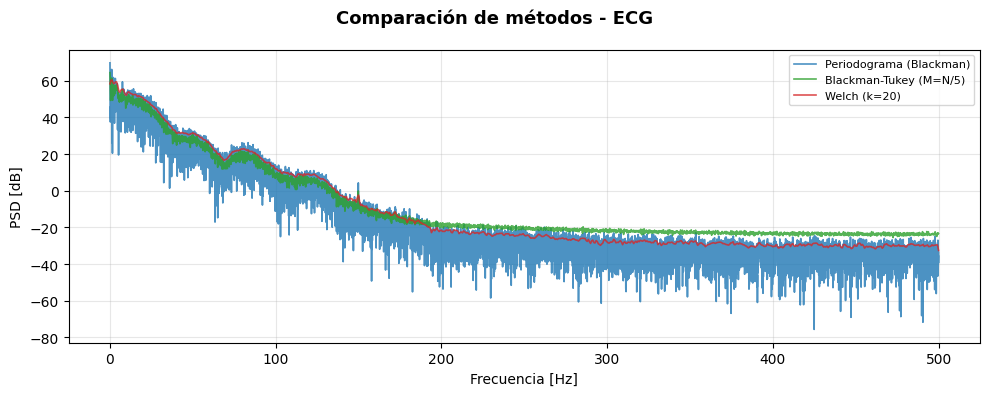

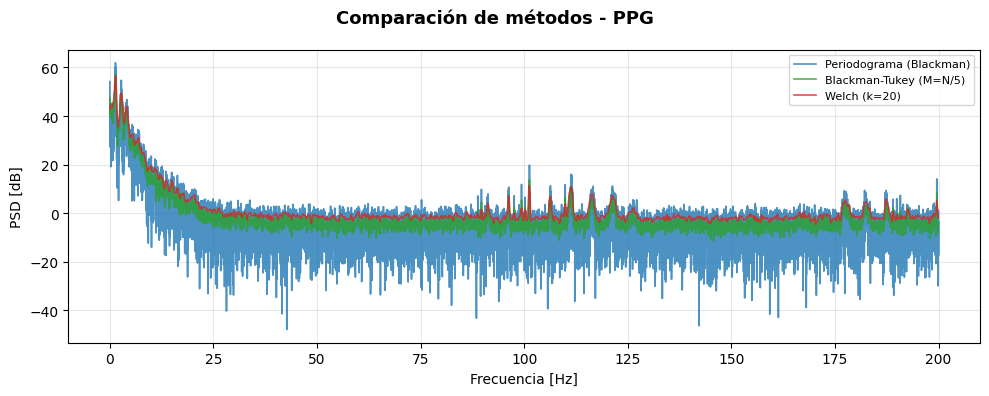

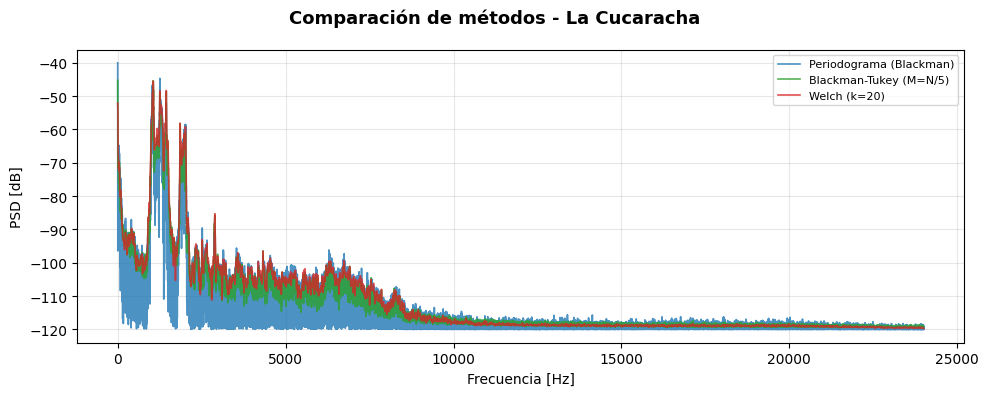

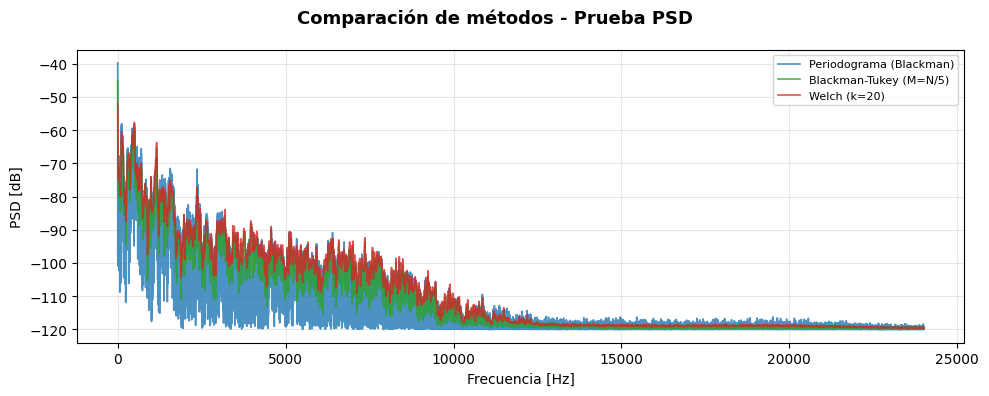

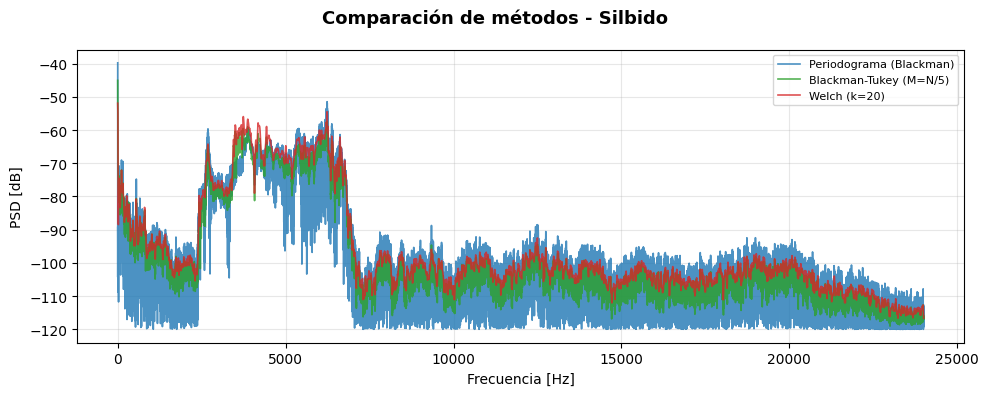

In [37]:
### Comparación: Periodograma ventaneado vs Welch vs Blackman-Tukey ###
for name, (x, fs, tipo) in data_dict.items():
    N   = len(x)

    # Periodograma ventaneado (Blackman)
    f_per, Pxx_per = periodograma_ventaneado(x, fs, sig.windows.blackman)

    # Welch con k=20 segmentos
    f_wel, Pxx_wel = sig.welch(x, fs=fs, nperseg=N//20, noverlap=None,
                                detrend=False, return_onesided=True,
                                scaling='density', average='mean')

    # Blackman-Tukey
    f_bt,  Pxx_bt  = blackman_tukey(x, fs=fs)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    fig.suptitle(f"Comparación de métodos - {name}", fontsize=13, fontweight='bold')

    ax.plot(f_per, 10*np.log10(Pxx_per + 1e-12), linewidth=1.2, alpha=0.8, label='Periodograma (Blackman)', color='tab:blue')
    ax.plot(f_bt,  10*np.log10(Pxx_bt  + 1e-12), linewidth=1.2, alpha=0.8, label='Blackman-Tukey (M=N/5)', color='tab:green')
    ax.plot(f_wel, 10*np.log10(Pxx_wel + 1e-12), linewidth=1.2, alpha=0.8, label='Welch (k=20)', color='tab:red')
    ax.set_xlabel("Frecuencia [Hz]");
    ax.set_ylabel("PSD [dB]")
    ax.legend(fontsize=8);
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

plt.show()


In [38]:
### Tabla comparativa de anchos de banda estimados ###

SEP = '=' * 72
sep = '-' * 72

print(f"\n{SEP}")
print(f"  Comparación de estimación de ancho de banda por método")
print(f"{SEP}")

# Pasabajos
pb_names = [n for n, r in bw_results.items() if r['tipo'] == PASABAJOS]
if pb_names:
    print(f"\n  Señales PASABAJOS  (criterio: 95 % de la potencia)")
    print(f"  {'Señal':<18} {'Welch (k=20)':<20} {'Periodograma (Blackman)':<26} {'Blackman-Tukey'}")
    print(f"  {sep}")
    for name in pb_names:
        r = bw_results[name]
        print(f"  {name:<18} {r.get('welch','—'):<20} {r.get('periodograma','—'):<26} {r.get('blackman_tukey','—')}")

# Pasabanda
pba_names = [n for n, r in bw_results.items() if r['tipo'] == PASABANDA]
if pba_names:
    print(f"\n  Señales PASABANDA  (criterio: 2.5 % – 97.5 % de la potencia)")
    print(f"  {'Señal':<18} {'Welch (k=20)':<20} {'Periodograma (Blackman)':<26} {'Blackman-Tukey'}")
    print(f"  {sep}")
    for name in pba_names:
        r = bw_results[name]
        print(f"  {name:<18} {r.get('welch','—'):<20} {r.get('periodograma','—'):<26} {r.get('blackman_tukey','—')}")

print(f"\n{SEP}\n")



  Comparación de estimación de ancho de banda por método

  Señales PASABAJOS  (criterio: 95 % de la potencia)
  Señal              Welch (k=20)         Periodograma (Blackman)    Blackman-Tukey
  ------------------------------------------------------------------------
  ECG                22.7 Hz              23.2 Hz                    22.3 Hz
  PPG                3.9 Hz               4.0 Hz                     4.0 Hz

  Señales PASABANDA  (criterio: 2.5 % – 97.5 % de la potencia)
  Señal              Welch (k=20)         Periodograma (Blackman)    Blackman-Tukey
  ------------------------------------------------------------------------
  La Cucaracha       6.7 – 1940.0 Hz      0.0 – 1976.7 Hz            0.7 – 1941.3 Hz
  Prueba PSD         0.0 – 1413.3 Hz      0.0 – 1560.7 Hz            0.0 – 1364.3 Hz
  Silbido            0.0 – 6493.3 Hz      0.0 – 6613.7 Hz            0.7 – 6487.7 Hz




# Conclusiones

- El criterio utilizado para estimar el ancho de banda a partir de la potencia acumulada resultó inadecuado para señales pasabanda. Asumir que el piso de ruido distribuye un 2,5% de la potencia en cada extremo del espectro no se sostiene en los experimentos porque las señales tenían componente de continua significativa.
- Esto se podría corregir en la estimación con Welch agregando detrending.
- Otra forma podría ser evaluando la derivada de la función de potencia acumulada normalizada Fx y comenzar a medir el ancho de banda a partir de un cambio abrupto en la pendiente.
- Comparando los tres métodos de estimación espectral para obtener el ancho de banda, se observan resultados similares entre sí, lo que indica que las diferencias en el resultado final no son atribuibles al método para obtener la PSD de la señal, sino principalmente al criterio de detección de las frecuencias de corte.
***
De todas formas se puede visualizar en los gráficos de PSD las propiedades de cada método:
- El periodograma ventaneado es el estimador con mayor varianza, su principal inconveniente es que esta no disminuye al aumentar N. Al utilizar toda la señal como un único segmento, la resolución frecuencial es máxima (Δf = fs/N).
- Welch reduce la varianza promediando k periodogramas de segmentos solapados. A mayor k (más segmentos), menor varianza pero menor resolución frecuencial (Δf = kfs/N). Con k = 20, el espectro resultante es notablemente más suave que el periodograma.
- Blackman-Tukey estima la PSD a través de la autocorrelación ventaneada. Su sesgo y varianza dependen de M. Valores de M pequeños reducen la varianza pero introducen sesgo, mientras que M cercano a N se aproxima al periodograma. Con M = N/5, el resultado en suavidad es intermedio entre el periodograma y Welch con k = 20.
- Finalmente, para las señales analizadas Welch con k = 20 produce la estimación espectral más limpia y es la más adecuada para estimar ancho de banda, siempre que se corrija el problema de la componente de continua mediante detrending previo.